Model Performance:
Root Mean Squared Error: 3.14 GPa
R² Score: 0.75


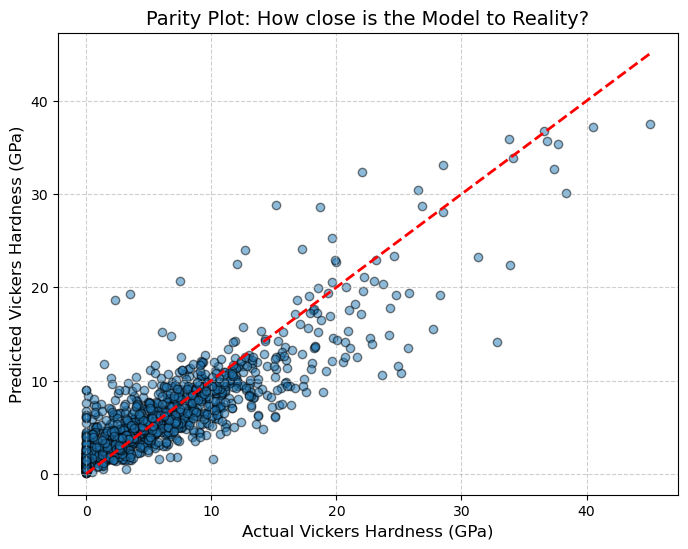

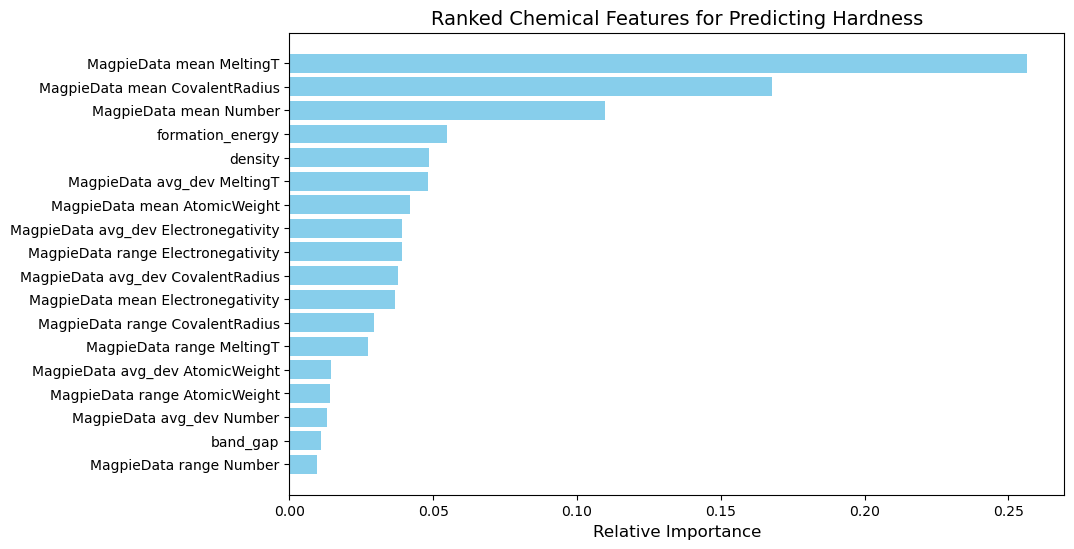

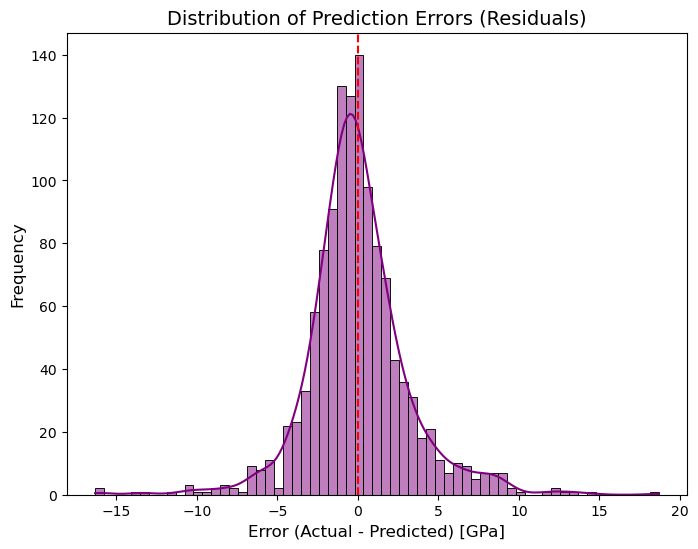

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

df = pd.read_csv("mp_hardness_advanced_v3.csv")

# Remove non-numeric columns like 'id', 'formula', and 'composition'
X = df.drop(columns=['id', 'formula', 'composition', 'vickers_hardness_gpa'])
y = df['vickers_hardness_gpa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#RF model 1
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

#RF model 2
#model = RandomForestRegressor(
#    n_estimators=500,     
#    max_features='sqrt',
#    max_depth=20,         
#    random_state=42
#)
#model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Performance:")
print(f"Root Mean Squared Error: {rmse:.2f} GPa")
print(f"R² Score: {r2:.2f}")

#Parity Plot (Predicted vs Actual)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line

plt.xlabel('Actual Vickers Hardness (GPa)', fontsize=12)
plt.ylabel('Predicted Vickers Hardness (GPa)', fontsize=12)
plt.title('Parity Plot: How close is the Model to Reality?', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Feature Importance Plot
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[:]

plt.figure(figsize=(10, 6))
plt.title('Ranked Chemical Features for Predicting Hardness', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance', fontsize=12)
plt.show()

#Residual/Error Histogram
residuals = y_test - predictions
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')

plt.title('Distribution of Prediction Errors (Residuals)', fontsize=14)
plt.xlabel('Error (Actual - Predicted) [GPa]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()